In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 50)

CLEANED = "../data/cleaned/"

df = pd.read_csv(CLEANED + "ecommerce_orders_features.csv")

# For order-level analysis, deduplicate by order_id
orders = df.drop_duplicates(subset='order_id').copy()

print(f"Item-level rows:  {len(df):,}")
print(f"Order-level rows: {len(orders):,}")
print(f"Columns: {df.shape[1]}")

Item-level rows:  110,189
Order-level rows: 96,470
Columns: 36


=== MONTHLY ORDER SUMMARY ===
order_month  total_orders  total_revenue
    2016-10           265      46,490.66
    2017-01           750     127,482.37
    2017-02          1653     271,239.32
    2017-03          2546     414,330.95
    2017-04          2303     390,812.40
    2017-05          3545     566,657.40
    2017-06          3135     490,050.37
    2017-07          3872     566,299.08
    2017-08          4193     645,832.36
    2017-09          4150     701,077.49
    2017-10          4478     751,117.01
    2017-11          7288   1,153,229.37
    2017-12          5513     843,078.29
    2018-01          7069   1,077,887.46
    2018-02          6555     966,168.41
    2018-03          7003   1,120,598.24
    2018-04          6798   1,132,878.93
    2018-05          6749   1,128,774.52
    2018-06          6096   1,011,448.96
    2018-07          6156   1,027,286.52
    2018-08          6351     985,491.64


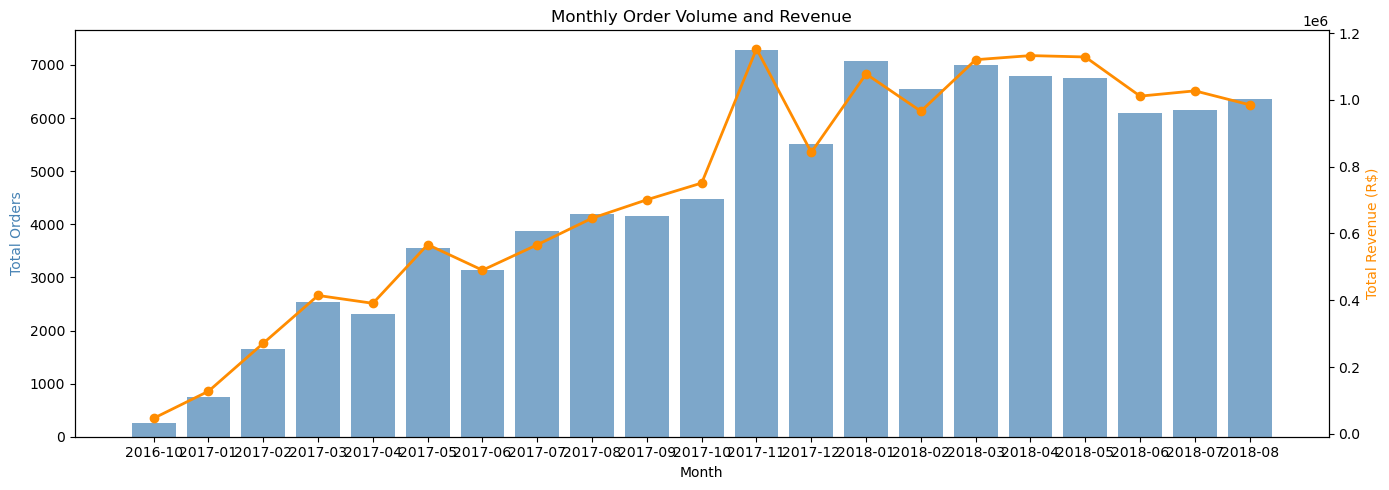


Finding: Which month had the peak orders?
  Peak month: 2017-11 — 7,288 orders, R$ 1,153,229.37


In [2]:
# ── Monthly orders and revenue trend ──────────────────────────────────────
monthly = df.groupby('order_month').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('revenue', 'sum')
).reset_index().sort_values('order_month')

# Remove incomplete boundary months (very low volume)
monthly = monthly[monthly['total_orders'] >= 100]

print("=== MONTHLY ORDER SUMMARY ===")
print(monthly.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['order_month'], monthly['total_orders'],
        color='steelblue', alpha=0.7, label='Orders')
ax2.plot(monthly['order_month'], monthly['total_revenue'],
         color='darkorange', linewidth=2, marker='o', label='Revenue')

ax1.set_xlabel('Month')
ax1.set_ylabel('Total Orders', color='steelblue')
ax2.set_ylabel('Total Revenue (R$)', color='darkorange')
plt.title('Monthly Order Volume and Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../screenshots/eda_monthly_trend.png', dpi=100)
plt.show()
print("\nFinding: Which month had the peak orders?")
peak = monthly.loc[monthly['total_orders'].idxmax()]
print(f"  Peak month: {peak['order_month']} — {peak['total_orders']:,} orders, R$ {peak['total_revenue']:,.2f}")

=== TOP 10 CATEGORIES BY REVENUE ===
product_category_name_english  total_orders  total_revenue  avg_review
                health_beauty          8647   1,412,089.53        4.19
                watches_gifts          5493   1,264,016.98        4.07
               bed_bath_table          9272   1,225,209.26        3.92
               sports_leisure          7529   1,118,062.91        4.17
        computers_accessories          6529   1,032,603.65        3.99
              furniture_decor          6307     880,329.92        3.95
                   housewares          5743     758,392.25        4.11
                   cool_stuff          3559     691,680.89        4.20
                         auto          3809     669,319.92        4.11
                 garden_tools          3448     567,145.68        4.08


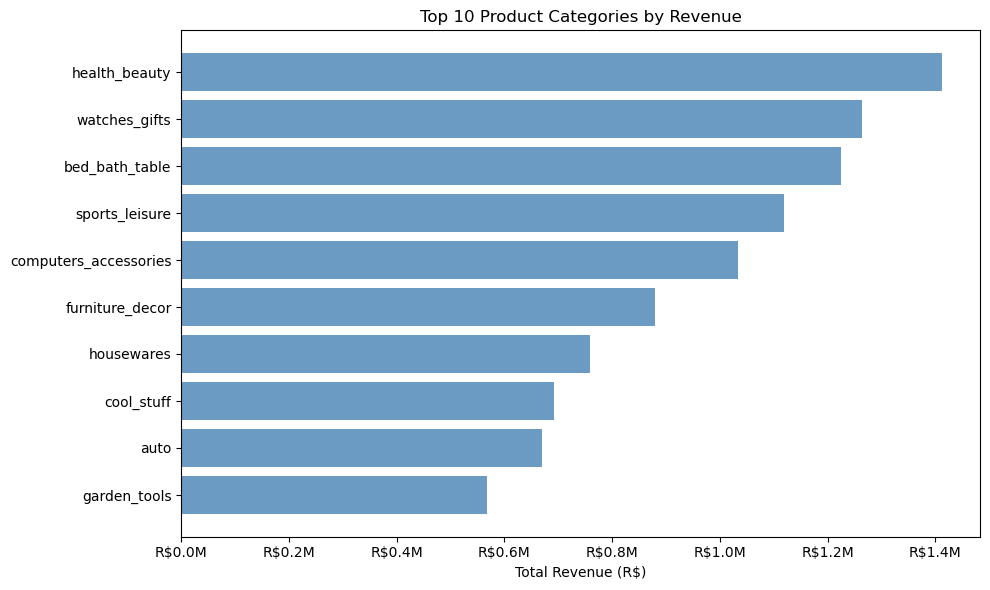

In [3]:
# ── Category revenue and order volume ─────────────────────────────────────
category = df.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('revenue', 'sum'),
    avg_review=('review_score', 'mean')
).reset_index().sort_values('total_revenue', ascending=False)

top10 = category.head(10)

print("=== TOP 10 CATEGORIES BY REVENUE ===")
print(top10[['product_category_name_english',
             'total_orders', 'total_revenue', 'avg_review']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['product_category_name_english'][::-1],
               top10['total_revenue'][::-1],
               color='steelblue', alpha=0.8)
ax.set_xlabel('Total Revenue (R$)')
ax.set_title('Top 10 Product Categories by Revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'R${x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('../screenshots/eda_category_revenue.png', dpi=100)
plt.show()

=== STATE DELIVERY PERFORMANCE (Top 10 Worst) ===
customer_state  total_orders  avg_delivery_days  late_delivery_rate
            AL           397              24.04               21.41
            MA           717              21.12               17.43
            SE           335              21.03               15.22
            PI           476              18.99               13.87
            CE          1279              20.82               13.76
            RR            41              28.98               12.20
            BA          3256              18.87               12.16
            RJ         12350              14.85               12.11
            PA           946              23.32               11.21
            ES          1995              15.33               10.73


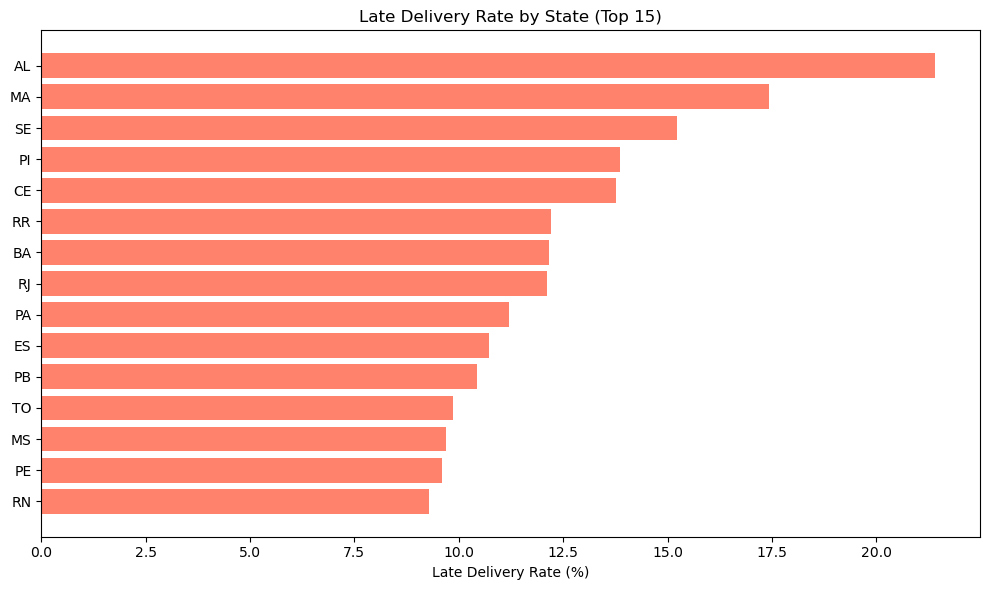

In [4]:
# ── Delivery performance by customer state ────────────────────────────────
state_delivery = orders.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    avg_delivery_days=('delivery_days', 'mean'),
    late_count=('is_late_delivery', lambda x: (x == 'Yes').sum())
).reset_index()

state_delivery['late_delivery_rate'] = (
    state_delivery['late_count'] / state_delivery['total_orders'] * 100
).round(2)

state_delivery['avg_delivery_days'] = state_delivery['avg_delivery_days'].round(2)
state_delivery = state_delivery.sort_values('late_delivery_rate', ascending=False)

print("=== STATE DELIVERY PERFORMANCE (Top 10 Worst) ===")
print(state_delivery.head(10)[['customer_state',
    'total_orders', 'avg_delivery_days', 'late_delivery_rate']].to_string(index=False))

top_states = state_delivery.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_states['customer_state'][::-1],
        top_states['late_delivery_rate'][::-1],
        color='tomato', alpha=0.8)
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_title('Late Delivery Rate by State (Top 15)')
plt.tight_layout()
plt.savefig('../screenshots/eda_state_delivery.png', dpi=100)
plt.show()

=== REVIEW SCORE BY DELIVERY STATUS ===
delivery_status  total_orders  avg_review_score  pct_5_star
           Late          6534              2.27       16.53
        On-Time         89936              4.29       62.27


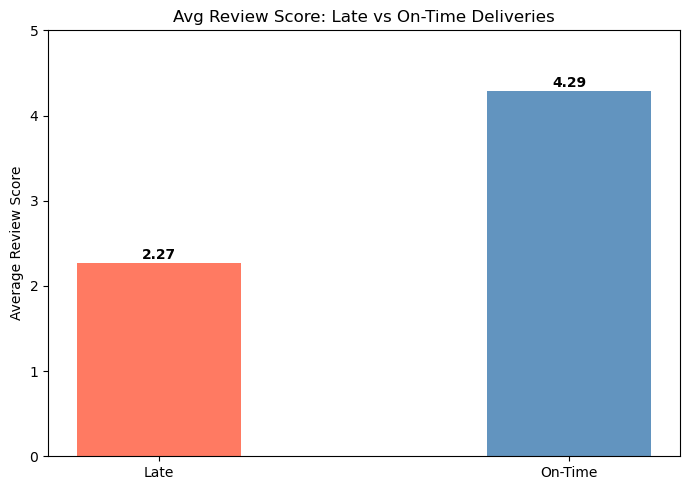


Finding: Late orders score 2.27 vs On-Time 4.29
  Difference: 2.02 points lower for late orders


In [5]:
# ── Do late deliveries get lower review scores? ───────────────────────────
review_delivery = orders.groupby('is_late_delivery').agg(
    total_orders=('order_id', 'count'),
    avg_review_score=('review_score', 'mean'),
    pct_5_star=('review_score', lambda x: (x == 5).sum() / x.count() * 100)
).reset_index()

review_delivery.columns = ['delivery_status', 'total_orders',
                            'avg_review_score', 'pct_5_star']
review_delivery['delivery_status'] = review_delivery['delivery_status'].map(
    {'Yes': 'Late', 'No': 'On-Time'})
review_delivery = review_delivery.sort_values('delivery_status')

print("=== REVIEW SCORE BY DELIVERY STATUS ===")
print(review_delivery.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['tomato' if s == 'Late' else 'steelblue'
          for s in review_delivery['delivery_status']]
bars = ax.bar(review_delivery['delivery_status'],
              review_delivery['avg_review_score'],
              color=colors, alpha=0.85, width=0.4)
ax.set_ylim(0, 5)
ax.set_ylabel('Average Review Score')
ax.set_title('Avg Review Score: Late vs On-Time Deliveries')
for bar, val in zip(bars, review_delivery['avg_review_score']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/eda_review_delivery.png', dpi=100)
plt.show()

diff = review_delivery.set_index('delivery_status')['avg_review_score']
print(f"\nFinding: Late orders score {diff['Late']:.2f} vs On-Time {diff['On-Time']:.2f}")
print(f"  Difference: {diff['On-Time'] - diff['Late']:.2f} points lower for late orders")

=== PAYMENT TYPE SUMMARY ===
dominant_payment_type  total_orders  avg_payment_value  avg_installments
          credit_card         73097             182.56              3.65
               boleto         19191             176.33              1.00
              voucher          2698             133.07              1.51
           debit_card          1483             149.20              1.00


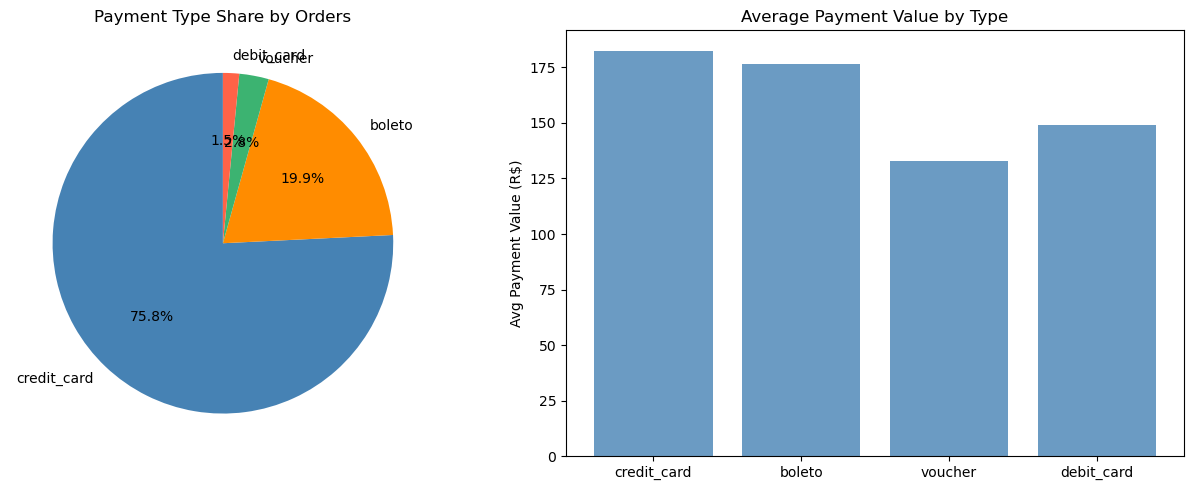

In [8]:
# ── Payment type usage and order value ────────────────────────────────────
payment = df.groupby('dominant_payment_type').agg(
    total_orders=('order_id', 'nunique'),
    avg_payment_value=('total_payment_value', 'mean'),
    avg_installments=('payment_installments', 'mean')
).reset_index().sort_values('total_orders', ascending=False)

print("=== PAYMENT TYPE SUMMARY ===")
print(payment.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(payment['total_orders'],
            labels=payment['dominant_payment_type'],
            autopct='%1.1f%%', startangle=90,
            colors=['steelblue', 'darkorange', 'mediumseagreen', 'tomato', 'purple'])
axes[0].set_title('Payment Type Share by Orders')

axes[1].bar(payment['dominant_payment_type'],
            payment['avg_payment_value'],
            color='steelblue', alpha=0.8)
axes[1].set_ylabel('Avg Payment Value (R$)')
axes[1].set_title('Average Payment Value by Type')
plt.tight_layout()
plt.savefig('../screenshots/eda_payment_types.png', dpi=100)
plt.show()

=== TOP 10 CATEGORIES BY AVERAGE FREIGHT COST ===
          product_category_name_english  avg_freight  avg_price  avg_freight_ratio
                      home_appliances_2        44.39     467.33               0.20
kitchen_dining_laundry_garden_furniture        42.12     166.18               0.35
                       office_furniture        40.20     160.76               0.27
                  furniture_living_room        35.75     136.06               0.33
         industry_commerce_and_business        28.62     144.58               0.29
                    luggage_accessories        27.93     128.79               0.26
                    musical_instruments        27.45     283.13               0.25
              construction_tools_lights        24.88     132.75               0.26
                       small_appliances        23.33     277.74               0.26
                      home_construction        22.84     136.59               0.27


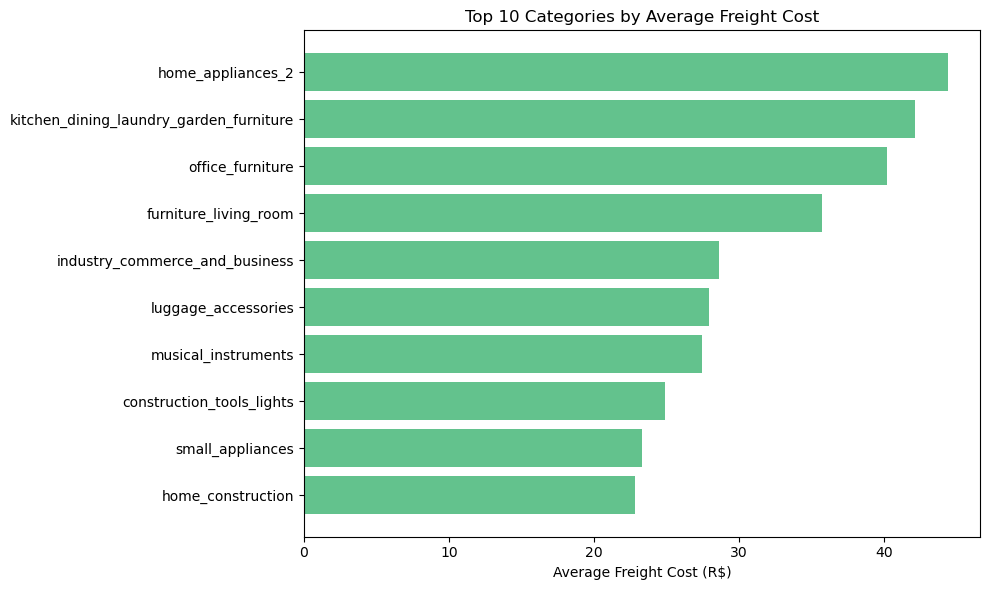

In [9]:
# ── Freight cost by category and delivery bucket ──────────────────────────
freight_category = df.groupby('product_category_name_english').agg(
    avg_freight=('freight_value', 'mean'),
    avg_price=('price', 'mean'),
    avg_freight_ratio=('freight_ratio', 'mean'),
    total_orders=('order_id', 'nunique')
).reset_index()

# Only categories with enough orders
freight_category = freight_category[
    freight_category['total_orders'] >= 200
].sort_values('avg_freight', ascending=False).head(10)

print("=== TOP 10 CATEGORIES BY AVERAGE FREIGHT COST ===")
print(freight_category[['product_category_name_english',
    'avg_freight', 'avg_price', 'avg_freight_ratio']].round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(freight_category['product_category_name_english'][::-1],
        freight_category['avg_freight'][::-1],
        color='mediumseagreen', alpha=0.8)
ax.set_xlabel('Average Freight Cost (R$)')
ax.set_title('Top 10 Categories by Average Freight Cost')
plt.tight_layout()
plt.savefig('../screenshots/eda_freight_category.png', dpi=100)
plt.show()

In [10]:
print("=" * 55)
print("  KEY FINDINGS — docs/key_findings_draft.md")
print("=" * 55)

peak_month = monthly.loc[monthly['total_orders'].idxmax(), 'order_month']
peak_orders = monthly['total_orders'].max()
top_cat = category.iloc[0]['product_category_name_english']
top_cat_rev = category.iloc[0]['total_revenue']
worst_state = state_delivery.iloc[0]['customer_state']
worst_late = state_delivery.iloc[0]['late_delivery_rate']
late_score = review_delivery.set_index('delivery_status')['avg_review_score']['Late']
ontime_score = review_delivery.set_index('delivery_status')['avg_review_score']['On-Time']
top_payment = payment.iloc[0]['dominant_payment_type']
top_payment_pct = payment.iloc[0]['total_orders'] / payment['total_orders'].sum() * 100

print(f"""
1. ORDERS PEAK:   {peak_month} had the highest activity with {peak_orders:,} orders.
2. TOP CATEGORY:  '{top_cat}' leads revenue at R$ {top_cat_rev:,.0f}.
3. WORST STATE:   '{worst_state}' has the highest late delivery rate at {worst_late:.1f}%.
4. REVIEW IMPACT: Late deliveries avg {late_score:.2f} vs {ontime_score:.2f} for on-time — 
                  a {ontime_score - late_score:.2f} point drop in satisfaction.
5. PAYMENT:       '{top_payment}' dominates at {top_payment_pct:.1f}% of all orders.
""")

  KEY FINDINGS — docs/key_findings_draft.md

1. ORDERS PEAK:   2017-11 had the highest activity with 7,288 orders.
2. TOP CATEGORY:  'health_beauty' leads revenue at R$ 1,412,090.
3. WORST STATE:   'AL' has the highest late delivery rate at 21.4%.
4. REVIEW IMPACT: Late deliveries avg 2.27 vs 4.29 for on-time — 
                  a 2.02 point drop in satisfaction.
5. PAYMENT:       'credit_card' dominates at 75.8% of all orders.

